# Experiment sigmoid region extraction + fitted/LUT model training

This notebook contains preprocessing/fitting code for the **experimental curves**, together with fitted/LUT-based training and inference code.

Workflow:
1. Load `measurement/Experiment_results.csv`  
   (`Current` + `x30`, `x40`, `x50`, `x60`, `x70`)
2. Search for the significant transition region based on a threshold
3. Extract only the significant region and shift / flip / scale it
4. Fit a sigmoid function to the preprocessed curve
5. Train/infer using the fitted sigmoid
6. Curve LUT-based inference


# **Load Experimental Data**


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

file_path = Path("measurement/Experiment_results.csv")

df = pd.read_csv(file_path)
df = df.apply(pd.to_numeric, errors="coerce")

curve_cols = [c for c in df.columns if c != "Current"]
print("file:", file_path)
print("shape:", df.shape)
print("curves:", curve_cols)
print(df.head())


file: Experiment_results.csv
shape: (65, 6)
curves: ['x30', 'x40', 'x50', 'x60', 'x70']
   Current      x30      x40      x50      x60      x70
0      0.0 -0.14320 -0.17902  0.32020 -0.69268 -0.33029
1     -0.5 -0.13352 -0.14287  0.28356 -0.64032 -0.30403
2     -1.0 -0.13295 -0.14635  0.28108 -0.64100 -0.30383
3     -1.5 -0.13658 -0.15972  0.28333 -0.63996 -0.30294
4     -2.0 -0.13609 -0.14525  0.28644 -0.63575 -0.30153


# **Finding the Appropriate Region for Fitting**

In [2]:
import numpy as np
import pandas as pd

def find_sigmoid_region(x, y, threshold_ratio=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return None

    dy = np.gradient(y, x)

    threshold = threshold_ratio * np.max(np.abs(dy))

    mask = np.abs(dy) > threshold

    regions = []
    start = None

    for i, m in enumerate(mask):
        if m and start is None:
            start = i
        elif (not m) and (start is not None):
            regions.append((start, i))
            start = None

    if start is not None:
        regions.append((start, len(mask)))

    if len(regions) == 0:
        return None

    lengths = [end - start for start, end in regions]
    idx = np.argmax(lengths)
    start, end = regions[idx]

    return {
        "dy": dy,
        "threshold": threshold,
        "mask": mask,
        "start_idx": start,
        "end_idx": end,
        "x_start": x[start],
        "x_end": x[end - 1],
    }

In [3]:
x = df["Current"].values

results = {}

for col in df.columns[1:]:
    y = df[col].values
    result = find_sigmoid_region(x, y, threshold_ratio=0.05)
    results[col] = result

summary = []
for col, res in results.items():
    if res is None:
        summary.append([col, None, None])
    else:
        summary.append([col, res["x_start"], res["x_end"]])

summary_df = pd.DataFrame(summary, columns=["name", "x_start", "x_end"])
print(summary_df)


  name  x_start  x_end
0  x30     -8.5  -21.0
1  x40     -7.5  -19.0
2  x50     -7.5  -20.0
3  x60     -9.0  -23.0
4  x70     -8.0  -20.5


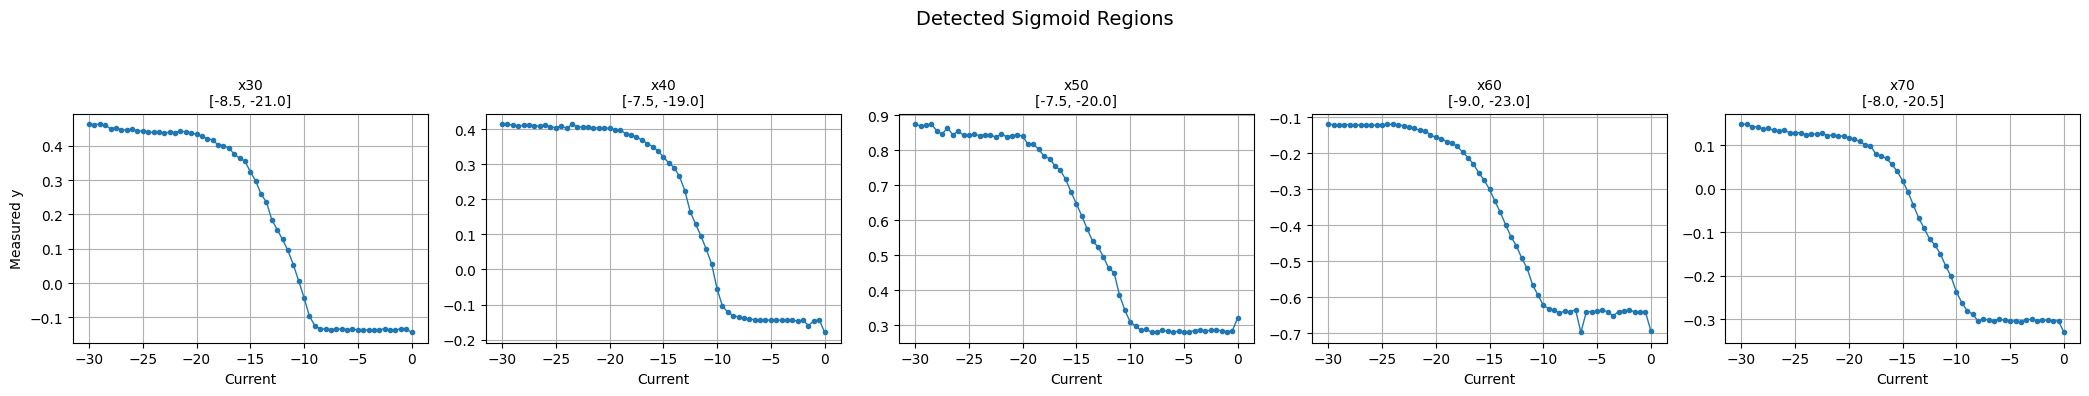

In [4]:
import matplotlib.pyplot as plt

n = len(df.columns) - 1
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4), sharex=True, sharey=False)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, df.columns[1:]):
    y = df[col].values
    res = results[col]

    ax.plot(x, y, marker="o", markersize=3, linewidth=1)

    if res is not None:
        title = f"{col}\n[{res['x_start']:.1f}, {res['x_end']:.1f}]"
    else:
        title = f"{col}\n[No region]"

    ax.set_title(title, fontsize=10)
    ax.grid(True)
    ax.set_xlabel("Current")

axes[0].set_ylabel("Measured y")
fig.suptitle("Detected Sigmoid Regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


# **Extract Significant Region + Shift / Flip / Scale**

In [5]:
import numpy as np
import pandas as pd

processed_curves = {}
summary_processed = []

for col in df.columns[1:]:
    y_all = df[col].values
    res = results.get(col, None)

    if res is None:
        processed_curves[col] = None
        summary_processed.append([col, None, None, None, None])
        continue

    start_idx = res["start_idx"]
    end_idx   = res["end_idx"]

    x_region = x[start_idx:end_idx].copy()
    y_region = y_all[start_idx:end_idx].copy()

    valid = np.isfinite(x_region) & np.isfinite(y_region)
    x_region = x_region[valid]
    y_region = y_region[valid]

    if len(x_region) < 3:
        processed_curves[col] = None
        summary_processed.append([col, None, None, None, None])
        continue

    x_center = 0.5 * (x_region.min() + x_region.max())
    x_shifted = x_region - x_center

    y_min = np.min(y_region)
    y_max = np.max(y_region)

    if np.isclose(y_max, y_min):
        processed_curves[col] = None
        summary_processed.append([col, None, None, None, None])
        continue

    y_scaled = (y_region - y_min) / (y_max - y_min)

    if y_scaled[0] > y_scaled[-1]:
        y_scaled = 1.0 - y_scaled

    corr = np.corrcoef(x_shifted, y_scaled)[0, 1]
    if np.isfinite(corr) and corr < 0:
        x_shifted = -x_shifted

    x_abs_max = np.max(np.abs(x_shifted))
    if np.isclose(x_abs_max, 0):
        processed_curves[col] = None
        summary_processed.append([col, None, None, None, None])
        continue

    x_scaled = x_shifted / x_abs_max * 6.0

    x_scaled = np.clip(x_scaled, -6.0, 6.0)

    processed_curves[col] = {
        "x_raw_region": x_region,
        "y_raw_region": y_region,
        "x_processed": x_scaled,
        "y_processed": y_scaled,
        "x_center": x_center,
        "y_min": y_min,
        "y_max": y_max,
        "x_start": x_region.min(),
        "x_end": x_region.max(),
    }

    summary_processed.append([
        col,
        x_region.min(),
        x_region.max(),
        x_center,
        len(x_region)
    ])

summary_processed_df = pd.DataFrame(
    summary_processed,
    columns=["name", "x_start", "x_end", "x_center", "num_points"]
)

print(summary_processed_df)


  name  x_start  x_end  x_center  num_points
0  x30    -21.0   -8.5    -14.75          26
1  x40    -19.0   -7.5    -13.25          24
2  x50    -20.0   -7.5    -13.75          26
3  x60    -23.0   -9.0    -16.00          29
4  x70    -20.5   -8.0    -14.25          26


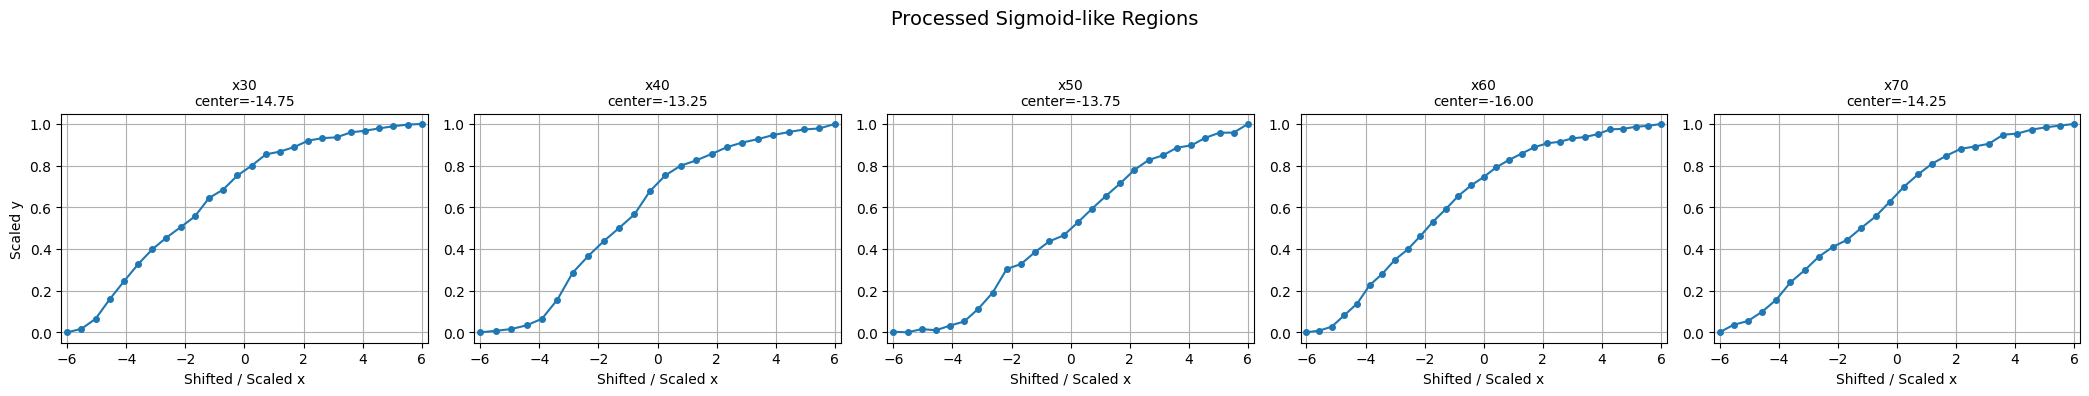

In [6]:
import matplotlib.pyplot as plt

cols = list(df.columns[1:])
n = len(cols)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4), sharex=False, sharey=False)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, cols):
    item = processed_curves.get(col, None)

    if item is None:
        ax.set_title(f"{col}\n[No valid region]", fontsize=10)
        ax.grid(True)
        continue

    xp = item["x_processed"]
    yp = item["y_processed"]

    ax.plot(xp, yp, marker="o", markersize=4, linewidth=1.5)
    ax.set_xlim(-6.2, 6.2)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{col}\ncenter={item['x_center']:.2f}", fontsize=10)
    ax.grid(True)
    ax.set_xlabel("Shifted / Scaled x")

axes[0].set_ylabel("Scaled y")
fig.suptitle("Processed Sigmoid-like Regions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


# **Sigmoid Fitting of Experimental Curves**


Curves: ['x30', 'x40', 'x50', 'x60', 'x70']
num_points: [26, 24, 26, 29, 26]


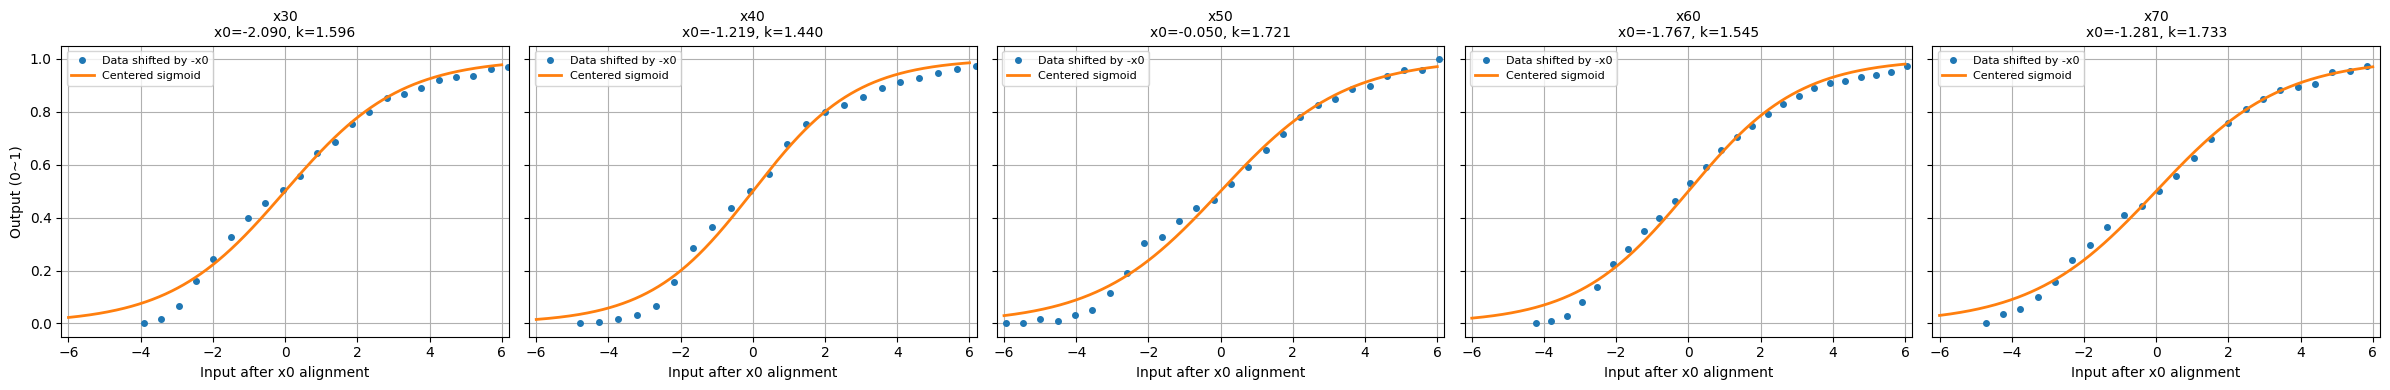

x0_list = [-2.08982341 -1.21913577 -0.0500746  -1.76723248 -1.28055628]
k_list  = [1.59554598 1.4397756  1.720776   1.5446931  1.73294035]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

selected_cols = list(df.columns[1:])
act_names = [f"act{i+1}_{col}" for i, col in enumerate(selected_cols)]

x_raw_list = []
y_raw_list = []
valid_selected_cols = []

for col in selected_cols:
    item = processed_curves.get(col, None)
    if item is None:
        print(f"[WARNING] {col} is None. Skip.")
        continue

    x_data = np.asarray(item["x_processed"], dtype=float)
    y_data = np.asarray(item["y_processed"], dtype=float)

    order = np.argsort(x_data)
    x_data = x_data[order]
    y_data = y_data[order]

    uniq_x = []
    uniq_y = []
    for xv in np.unique(x_data):
        m = x_data == xv
        uniq_x.append(xv)
        uniq_y.append(y_data[m].mean())
    x_data = np.asarray(uniq_x, dtype=float)
    y_data = np.asarray(uniq_y, dtype=float)

    x_raw_list.append(x_data)
    y_raw_list.append(y_data)
    valid_selected_cols.append(col)

print("Curves:", valid_selected_cols)
print("num_points:", [len(x) for x in x_raw_list])

# ----------------------------------------------------------
# Sigmoid fitting
# ----------------------------------------------------------
def sigmoid_shifted(x, x0, k):
    return 1.0 / (1.0 + np.exp(-(x - x0) / k))

def sigmoid_centered(x, k):
    return 1.0 / (1.0 + np.exp(-(x / k)))

x0_list = []
k_list = []
fit_info = {}

if len(x_raw_list) == 0:
    raise RuntimeError("No valid curves. Check processed_curves.")

fig, axes = plt.subplots(1, len(x_raw_list), figsize=(4.8 * len(x_raw_list), 4), sharey=True)
if len(x_raw_list) == 1:
    axes = [axes]

xx = np.linspace(-6, 6, 600)

for i, (col, x_data, y_data) in enumerate(zip(valid_selected_cols, x_raw_list, y_raw_list)):
    ax = axes[i]

    params, _ = curve_fit(
        sigmoid_shifted,
        x_data,
        y_data,
        p0=[0.0, 1.0],
        bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
        maxfev=20000,
    )
    x0_fit, k_fit = params

    x0_list.append(float(x0_fit))
    k_list.append(float(k_fit))

    x_aligned = x_data - x0_fit
    yy = sigmoid_centered(xx, k_fit)

    ax.plot(x_aligned, y_data, "o", ms=4, label="Data shifted by -x0")
    ax.plot(xx, yy, "-", lw=2, label="Centered sigmoid")
    ax.set_title(f"{col}\nx0={x0_fit:.3f}, k={k_fit:.3f}", fontsize=10)
    ax.set_xlim(-6.2, 6.2)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True)
    ax.legend(fontsize=8)

    fit_info[col] = {
        "x0": float(x0_fit),
        "k": float(k_fit),
        "x_data": x_data,
        "y_data": y_data,
        "x_aligned": x_aligned,
    }

axes[0].set_ylabel("Output (0~1)")
for ax in axes:
    ax.set_xlabel("Input after x0 alignment")

plt.tight_layout()
plt.show()

x0_list = np.asarray(x0_list, dtype=float)
k_list = np.asarray(k_list, dtype=float)

print("x0_list =", x0_list)
print("k_list  =", k_list)


# **Dataloader / Train-Test / Model**

# **1. Dataloader (MNIST / Fashion-MNIST / EMNIST Characters)**

Code to prepare the MNIST / Fashion-MNIST / EMNIST Characters datasets  
Downloads images and labels


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("gpu name:", torch.cuda.get_device_name(0))

In [9]:

import sys 
print(sys.executable)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(46)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
])

def get_loaders(dataset_name: str, batch_size=128, num_workers=2, val_ratio=0.1, seed=42):

    if dataset_name == "mnist":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

        full_train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
        test_ds       = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
        num_classes = 10

    elif dataset_name == "fashion":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,))
        ])

        full_train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
        test_ds       = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
        num_classes = 10

    elif dataset_name.startswith("emnist_"):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

        split = dataset_name.replace("emnist_", "")
        full_train_ds = datasets.EMNIST(root="./data", split=split, train=True, download=True, transform=transform)
        test_ds       = datasets.EMNIST(root="./data", split=split, train=False, download=True, transform=transform)

        if split == "balanced":
            num_classes = 47
        elif split == "letters":
            num_classes = 26
        elif split == "byclass":
            num_classes = 62
        else:
            raise ValueError("Unknown EMNIST split:", split)

    else:
        raise ValueError("Unknown dataset_name:", dataset_name)

    val_size = int(len(full_train_ds) * val_ratio)
    train_size = len(full_train_ds) - val_size
    train_ds, val_ds = random_split(
        full_train_ds,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader, num_classes


# **2. Train/Test Loop + Model Training**  

Create a function that takes a model and dataset and runs Train/Test

In [10]:
from torch.optim import Adam

def fix_emnist_letters_labels(y):
    return y - 1

@torch.no_grad()
def evaluate(model, loader, dataset_name: str):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if dataset_name == "emnist_letters":
            y = fix_emnist_letters_labels(y)

        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total


def train_one(model, train_loader, val_loader, test_loader, dataset_name: str, epochs=10, lr=1e-3):
    model = model.to(device)
    opt = Adam(model.parameters(), lr=lr, weight_decay=4e-5)
    scheduler = ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = {"train_acc": [], "val_acc": [], "test_acc": None}

    train_acc_0 = evaluate(model, train_loader, dataset_name)
    val_acc_0   = evaluate(model, val_loader, dataset_name)
    history["train_acc"].append(train_acc_0)
    history["val_acc"].append(val_acc_0)

    print(f"[{dataset_name}] epoch 00 | train_acc={train_acc_0:.4f} val_acc={val_acc_0:.4f}")

    for ep in range(1, epochs+1):
        model.train()

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            if dataset_name == "emnist_letters":
                y = fix_emnist_letters_labels(y)

            opt.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            opt.step()

        train_acc = evaluate(model, train_loader, dataset_name)
        val_acc   = evaluate(model, val_loader, dataset_name)
        scheduler.step(val_acc)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        current_lr = opt.param_groups[0]["lr"]
        print(f"[{dataset_name}] epoch {ep:02d} | train_acc={train_acc:.4f} val_acc={val_acc:.4f} lr={current_lr:.2e}")

    test_acc = evaluate(model, test_loader, dataset_name)
    history["test_acc"] = test_acc
    print(f"[{dataset_name}] final test_acc={test_acc:.4f}")

    return history, model


# **3. Ideal Model Design (MLP 784-384-192-128)**

Create the neural network model  
Uses 3 hidden layers (384, 192, 128) (same architecture as Figure 5a in the main text)


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class IdealSigmoid(nn.Module):
    def forward(self, x):
        return torch.sigmoid(x)

class MLP784_384_192_128(nn.Module):
    def __init__(self, num_classes: int, activation: nn.Module | None = None):
        super().__init__()
        self.fc1 = nn.Linear(784, 384)
        self.bn1 = nn.BatchNorm1d(384)
        self.fc2 = nn.Linear(384, 192)
        self.bn2 = nn.BatchNorm1d(192)
        self.fc3 = nn.Linear(192, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, num_classes)
        self.act = activation if activation is not None else IdealSigmoid()

    def forward(self, x):
        if x.dim() == 4:
            x = x.view(x.size(0), -1)
        x = self.act(self.bn1(self.fc1(x)))
        x = self.act(self.bn2(self.fc2(x)))
        x = self.act(self.bn3(self.fc3(x)))
        return self.fc4(x)

# **4. Model Execution Example**

Run Train/Test using the ideal sigmoid function

In [12]:

EPOCHS = 40
LR = 5e-4

hist_ideal = {}

# 3) Fashion MNIST
fashion_train, fashion_val, fashion_test, fashion_C = get_loaders("fashion")
model_fashion = MLP784_384_192_128(num_classes=fashion_C)
hist_fashion, _ = train_one(model_fashion, fashion_train, fashion_val, fashion_test,
                            "fashion", epochs=EPOCHS, lr=LR)
hist_ideal["fashion"] = hist_fashion

# 1) MNIST
mnist_train, mnist_val, mnist_test, mnist_C = get_loaders("mnist")
model_mnist = MLP784_384_192_128(num_classes=mnist_C)
hist_mnist, _ = train_one(model_mnist, mnist_train, mnist_val, mnist_test,
                          "mnist", epochs=EPOCHS, lr=LR)
hist_ideal["mnist"] = hist_mnist


# 2) EMNIST letters
emnist_train, emnist_val, emnist_test, emnist_C = get_loaders("emnist_letters")
model_emnist = MLP784_384_192_128(num_classes=emnist_C)
hist_emnist, _ = train_one(model_emnist, emnist_train, emnist_val, emnist_test,
                           "emnist_letters", epochs=EPOCHS, lr=LR)
hist_ideal["emnist_letters"] = hist_emnist


[fashion] epoch 00 | train_acc=0.1007 val_acc=0.0937
[fashion] epoch 01 | train_acc=0.8459 val_acc=0.8313 lr=5.00e-04
[fashion] epoch 02 | train_acc=0.8657 val_acc=0.8520 lr=5.00e-04
[fashion] epoch 03 | train_acc=0.8639 val_acc=0.8513 lr=5.00e-04
[fashion] epoch 04 | train_acc=0.8811 val_acc=0.8640 lr=5.00e-04
[fashion] epoch 05 | train_acc=0.8876 val_acc=0.8650 lr=5.00e-04
[fashion] epoch 06 | train_acc=0.8888 val_acc=0.8653 lr=5.00e-04
[fashion] epoch 07 | train_acc=0.8922 val_acc=0.8698 lr=5.00e-04
[fashion] epoch 08 | train_acc=0.9011 val_acc=0.8748 lr=5.00e-04
[fashion] epoch 09 | train_acc=0.9001 val_acc=0.8747 lr=5.00e-04
[fashion] epoch 10 | train_acc=0.9019 val_acc=0.8735 lr=5.00e-04
[fashion] epoch 11 | train_acc=0.9067 val_acc=0.8790 lr=5.00e-04
[fashion] epoch 12 | train_acc=0.9024 val_acc=0.8727 lr=5.00e-04
[fashion] epoch 13 | train_acc=0.9145 val_acc=0.8858 lr=5.00e-04
[fashion] epoch 14 | train_acc=0.9061 val_acc=0.8705 lr=5.00e-04
[fashion] epoch 15 | train_acc=0.9133

# **5. Fitted-Sigmoid-Based Model**

Uses the `x0_list` and `k_list` obtained directly from fitting the curves (`x30`, `x40`, `x50`, `x60`, `x70`) loaded above.  
The hard-coded `y_raw1~5` / `x0_list` / `k_list` from the earlier second version of the code have therefore been removed.


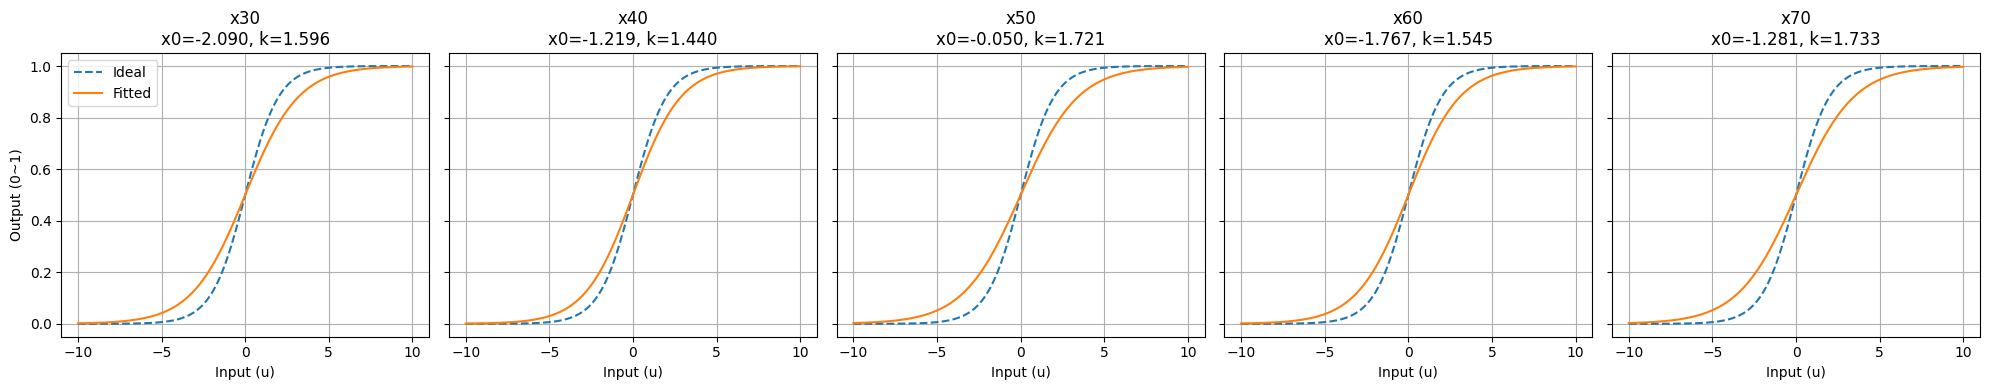

In [13]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class FittedSigmoid(nn.Module):
    """
    Centered sigmoid(z/k) using the fitted k, so output=0.5 at z=0.
    """
    def __init__(self, x0, k):
        super().__init__()
        self.register_buffer("x0", torch.tensor(float(x0)))
        self.register_buffer("k", torch.tensor(float(k)))

    def forward(self, z):
        return torch.sigmoid(z / self.k)

ideal_act = IdealSigmoid()

u = torch.linspace(-10, 10, 2000)
ideal = ideal_act(u)

fig, axes = plt.subplots(1, len(k_list), figsize=(4 * len(k_list), 4), sharey=True)
if len(k_list) == 1:
    axes = [axes]

for i in range(len(k_list)):
    ax = axes[i]
    fitted_act = FittedSigmoid(x0_list[i], k_list[i])
    fitted = fitted_act(u)

    ax.plot(u.numpy(), ideal.numpy(), '--', label='Ideal')
    ax.plot(u.numpy(), fitted.detach().numpy(), '-', label='Fitted')
    title_name = valid_selected_cols[i] if i < len(valid_selected_cols) else f"act{i+1}"
    ax.set_title(f"{title_name}\nx0={x0_list[i]:.3f}, k={k_list[i]:.3f}")
    ax.set_xlabel("Input (u)")
    ax.grid(True)

axes[0].set_ylabel("Output (0~1)")
axes[0].legend()
plt.tight_layout()
plt.show()


# **6. Fitted-Sigmoid-Based Model Test**

Run Train/Test using the fitted sigmoid

In [14]:

EPOCHS = 40
LR = 1e-3

hist = {}
trained_models = {}


mnist_train, mnist_val, mnist_test, mnist_C = get_loaders("mnist")
emnist_train, emnist_val, emnist_test, emnist_C = get_loaders("emnist_letters")
fashion_train, fashion_val, fashion_test, fashion_C = get_loaders("fashion")

for i in range(5):

    print(f"\n==============================")
    print(f"Activation {i+1}")
    print(f"x0 = {x0_list[i]:.4f}, k = {k_list[i]:.4f}")
    print(f"==============================")

    act_fit = FittedSigmoid(x0_list[i], k_list[i])

    hist[f"act{i+1}"] = {}
    trained_models[f"act{i+1}"] = {}

    # -------------------------------------------------
    # MNIST
    # -------------------------------------------------
    model_mnist = MLP784_384_192_128(num_classes=mnist_C, activation=act_fit)

    hist_mnist, trained_mnist = train_one(
        model_mnist,
        mnist_train,
        mnist_val,
        mnist_test,
        "mnist",
        epochs=EPOCHS,
        lr=LR
    )

    hist[f"act{i+1}"]["mnist"] = hist_mnist
    trained_models[f"act{i+1}"]["mnist"] = trained_mnist

    # -------------------------------------------------
    # EMNIST
    # -------------------------------------------------
    model_emnist = MLP784_384_192_128(num_classes=emnist_C, activation=act_fit)

    hist_emnist, trained_emnist = train_one(
        model_emnist,
        emnist_train,
        emnist_val,
        emnist_test,
        "emnist_letters",
        epochs=EPOCHS,
        lr=LR
    )

    hist[f"act{i+1}"]["emnist_letters"] = hist_emnist
    trained_models[f"act{i+1}"]["emnist_letters"] = trained_emnist

    # -------------------------------------------------
    # Fashion MNIST
    # -------------------------------------------------
    model_fashion = MLP784_384_192_128(num_classes=fashion_C, activation=act_fit)

    hist_fashion, trained_fashion = train_one(
        model_fashion,
        fashion_train,
        fashion_val,
        fashion_test,
        "fashion",
        epochs=EPOCHS,
        lr=LR
    )

    hist[f"act{i+1}"]["fashion"] = hist_fashion
    trained_models[f"act{i+1}"]["fashion"] = trained_fashion



Activation 1
x0 = -2.0898, k = 1.5955
[mnist] epoch 00 | train_acc=0.1039 val_acc=0.1093
[mnist] epoch 01 | train_acc=0.9009 val_acc=0.8927 lr=1.00e-03
[mnist] epoch 02 | train_acc=0.9167 val_acc=0.9125 lr=1.00e-03
[mnist] epoch 03 | train_acc=0.9471 val_acc=0.9363 lr=1.00e-03
[mnist] epoch 04 | train_acc=0.9512 val_acc=0.9390 lr=1.00e-03
[mnist] epoch 05 | train_acc=0.9669 val_acc=0.9553 lr=1.00e-03
[mnist] epoch 06 | train_acc=0.9735 val_acc=0.9625 lr=1.00e-03
[mnist] epoch 07 | train_acc=0.9741 val_acc=0.9627 lr=1.00e-03
[mnist] epoch 08 | train_acc=0.9789 val_acc=0.9638 lr=1.00e-03
[mnist] epoch 09 | train_acc=0.9821 val_acc=0.9697 lr=1.00e-03
[mnist] epoch 10 | train_acc=0.9831 val_acc=0.9700 lr=1.00e-03
[mnist] epoch 11 | train_acc=0.9840 val_acc=0.9702 lr=1.00e-03
[mnist] epoch 12 | train_acc=0.9872 val_acc=0.9715 lr=1.00e-03
[mnist] epoch 13 | train_acc=0.9851 val_acc=0.9718 lr=1.00e-03
[mnist] epoch 14 | train_acc=0.9878 val_acc=0.9722 lr=1.00e-03
[mnist] epoch 15 | train_acc

# **7. Epochs vs. Accuracy Plots**

Generate result plots and CSV files

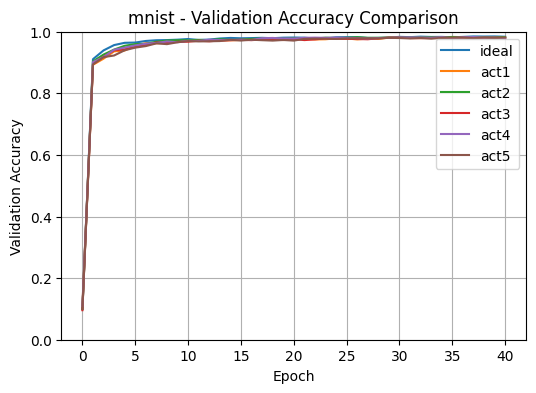

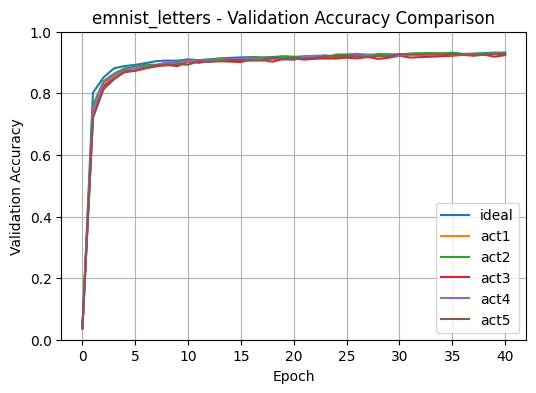

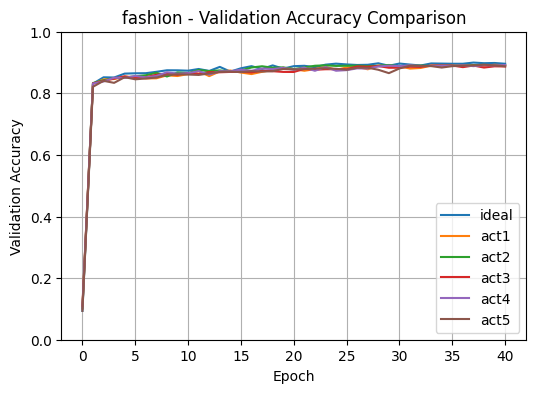

mnist_train_validation_accuracy.csv saved
emnist_letters_train_validation_accuracy.csv saved
fashion_train_validation_accuracy.csv saved
table1_test_accuracy.csv saved


,xRe [%],MNIST Digits [%],Fashion MNIST [%],MNIST Characters [%]
0,Ideal Sigmoid,98.60,90.00,92.67
1,30 %,98.34,89.09,92.40
2,40 %,98.33,89.27,92.57
3,50 %,98.10,88.79,91.95
4,60 %,98.31,89.16,92.30
5,70 %,98.30,88.79,92.24


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

datasets = ["mnist", "emnist_letters", "fashion"]

# validation accuracy plot
for ds in datasets:

    plt.figure(figsize=(6,4))

    # ideal activation
    acc = hist_ideal[ds]["val_acc"]
    plt.plot(range(len(acc)), acc, label="ideal")

    # fitted activations (act1~act5)
    for i in range(1,6):
        acc = hist[f"act{i}"][ds]["val_acc"]
        plt.plot(range(len(acc)), acc, label=f"act{i}")

    plt.ylim(0,1)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title(f"{ds} - Validation Accuracy Comparison")
    plt.grid(True)
    plt.legend()
    plt.show()


for ds in datasets:

    epochs = range(0, len(hist_ideal[ds]["val_acc"]))

    data = {
        "epoch": list(epochs),
        "ideal_train_acc": hist_ideal[ds]["train_acc"],
        "ideal_val_acc": hist_ideal[ds]["val_acc"],
    }

    for i in range(1,6):
        data[f"act{i}_train_acc"] = hist[f"act{i}"][ds]["train_acc"]
        data[f"act{i}_val_acc"]   = hist[f"act{i}"][ds]["val_acc"]

    df = pd.DataFrame(data)

    filename = f"{ds}_train_validation_accuracy.csv"
    df.to_csv(filename, index=False)

    print(f"{filename} saved")


dataset_labels = {
    "mnist": "MNIST Digits [%]",
    "fashion": "Fashion MNIST [%]",
    "emnist_letters": "MNIST Characters [%]",
}
column_order = ["MNIST Digits [%]", "Fashion MNIST [%]", "MNIST Characters [%]"]

table1_rows = []

row = {"xRe [%]": "Ideal Sigmoid"}
for ds in datasets:
    row[dataset_labels[ds]] = round(hist_ideal[ds]["test_acc"] * 100, 2)
table1_rows.append(row)

for i, col in enumerate(valid_selected_cols, start=1):
    comp = col.lstrip("x")
    row = {"xRe [%]": f"{comp} %"}
    for ds in datasets:
        row[dataset_labels[ds]] = round(hist[f"act{i}"][ds]["test_acc"] * 100, 2)
    table1_rows.append(row)

df_table1 = pd.DataFrame(table1_rows, columns=["xRe [%]"] + column_order)
df_table1.to_csv("table1_test_accuracy.csv", index=False)
print("table1_test_accuracy.csv saved")
display(df_table1)


# **8. LUT-Based Inference**

In [16]:

import copy
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

class ExperimentalLinearLUT(nn.Module):
    def __init__(self, x_points, y_points, clip_min=-5.0, clip_max=5.0):
        super().__init__()

        x_points = np.asarray(x_points, dtype=np.float32)
        y_points = np.asarray(y_points, dtype=np.float32)

        mask = (x_points >= clip_min) & (x_points <= clip_max)
        x_points = x_points[mask]
        y_points = y_points[mask]

        order = np.argsort(x_points)
        x_points = x_points[order]
        y_points = y_points[order]

        assert len(x_points) == len(y_points), "x_points and y_points length mismatch"
        assert len(x_points) >= 2, "Need at least 2 LUT points in clip range"
        assert np.all(np.diff(x_points) > 0), "x_points must be strictly increasing"

        self.register_buffer("x_points", torch.tensor(x_points, dtype=torch.float32))
        self.register_buffer("y_points", torch.tensor(y_points, dtype=torch.float32))

        self.clip_min = float(clip_min)
        self.clip_max = float(clip_max)

    def forward(self, z):
        x = self.x_points
        y = self.y_points

        out = torch.empty_like(z)

        left_mask = z < self.clip_min
        out[left_mask] = 0.0

        right_mask = z > self.clip_max
        out[right_mask] = 1.0

        mid_mask = (~left_mask) & (~right_mask)
        z_mid = z[mid_mask]

        if z_mid.numel() > 0:
            z_mid = torch.clamp(z_mid, min=x[0], max=x[-1])

            idx = torch.bucketize(z_mid, x)
            idx0 = torch.clamp(idx - 1, 0, len(x) - 2)
            idx1 = idx0 + 1

            x0 = x[idx0]
            x1 = x[idx1]
            y0 = y[idx0]
            y1 = y[idx1]

            t = (z_mid - x0) / (x1 - x0 + 1e-12)
            out[mid_mask] = y0 + t * (y1 - y0)

        return out

@torch.no_grad()
def evaluate_model(model, loader, dataset_name: str):
    model.eval()
    correct, total = 0, 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        if dataset_name == "emnist_letters":
            y_batch = fix_emnist_letters_labels(y_batch)

        logits = model(x_batch)
        pred = logits.argmax(dim=1)

        correct += (pred == y_batch).sum().item()
        total += y_batch.size(0)

    return correct / total

test_loaders = {
    "mnist": mnist_test,
    "emnist_letters": emnist_test,
    "fashion": fashion_test,
}

lut_results = []

for i in range(len(y_raw_list)):
    act_name = f"act{i+1}"
    title_name = valid_selected_cols[i] if i < len(valid_selected_cols) else act_name


    x_lut = np.asarray(x_raw_list[i], dtype=np.float32)
    y_lut = np.asarray(y_raw_list[i], dtype=np.float32)

    x_lut = x_lut - np.float32(x0_list[i])

    lut_act = ExperimentalLinearLUT(
        x_lut,
        y_lut,
        clip_min=-5.0,
        clip_max=5.0
    ).to(device)

    print("\n" + "=" * 60)
    print(f"{act_name} ({title_name}) | LUT-based inference")
    print("=" * 60)

    print(f"x0 shift applied: x_lut <- x_lut - ({x0_list[i]:.4f})")
    print(
        f"LUT used x-range: "
        f"[{lut_act.x_points[0].item():.4f}, {lut_act.x_points[-1].item():.4f}], "
        f"points={len(lut_act.x_points)}, outside=[0/1 clip]"
    )
    
    for ds_name in ["mnist", "emnist_letters", "fashion"]:
        trained_model = trained_models[act_name][ds_name]

        orig_act = FittedSigmoid(x0_list[i], k_list[i]).to(device)

        acc_orig = evaluate_model(trained_model, test_loaders[ds_name], ds_name)

        trained_model.act = lut_act
        acc_lut = evaluate_model(trained_model, test_loaders[ds_name], ds_name)

        trained_model.act = orig_act

        lut_results.append({
            "activation": act_name,
            "curve": title_name,
            "dataset": ds_name,
            "orig_acc": acc_orig,
            "lut_inference_acc": acc_lut
        })

        print(f"{ds_name:15s} -> orig = {acc_orig:.4f}, lut = {acc_lut:.4f}")

df_lut = pd.DataFrame(lut_results)

table2_rows = []
for col in valid_selected_cols:
    comp = col.lstrip("x")
    row = {"xRe [%]": f"{comp} %"}
    for ds in ["mnist", "fashion", "emnist_letters"]:
        match = df_lut[(df_lut["curve"] == col) & (df_lut["dataset"] == ds)]
        row[dataset_labels[ds]] = round(match["lut_inference_acc"].values[0] * 100, 2)
    table2_rows.append(row)

df_table2 = pd.DataFrame(table2_rows, columns=["xRe [%]"] + column_order)
display(df_table2)



act1 (x30) | LUT-based inference
x0 shift applied: x_lut <- x_lut - (-2.0898)
LUT used x-range: [-3.9102, 4.7298], points=19, outside=[0/1 clip]
mnist           -> orig = 0.9834, lut = 0.9621
emnist_letters  -> orig = 0.9240, lut = 0.8919
fashion         -> orig = 0.8909, lut = 0.8663

act2 (x40) | LUT-based inference
x0 shift applied: x_lut <- x_lut - (-1.2191)
LUT used x-range: [-4.7809, 4.6104], points=19, outside=[0/1 clip]
mnist           -> orig = 0.9833, lut = 0.9714
emnist_letters  -> orig = 0.9257, lut = 0.9068
fashion         -> orig = 0.8927, lut = 0.8751

act3 (x50) | LUT-based inference
x0 shift applied: x_lut <- x_lut - (-0.0501)
LUT used x-range: [-4.9899, 4.6101], points=21, outside=[0/1 clip]
mnist           -> orig = 0.9810, lut = 0.9376
emnist_letters  -> orig = 0.9195, lut = 0.8692
fashion         -> orig = 0.8879, lut = 0.8539

act4 (x60) | LUT-based inference
x0 shift applied: x_lut <- x_lut - (-1.7672)
LUT used x-range: [-4.2328, 4.7672], points=22, outside=[0/1

,xRe [%],MNIST Digits [%],Fashion MNIST [%],MNIST Characters [%]
0,30 %,96.21,86.63,89.19
1,40 %,97.14,87.51,90.68
2,50 %,93.76,85.39,86.92
3,60 %,97.19,87.85,90.67
4,70 %,96.22,86.94,89.19


In [17]:
df_lut.to_csv("lut_inference_results.csv", index=False)
print("lut_inference_results.csv saved")

df_table2.to_csv("table2_lut_inference_accuracy.csv", index=False)
print("table2_lut_inference_accuracy.csv saved")

lut_inference_results.csv saved
table2_lut_inference_accuracy.csv saved
